# Phase B: Regime and execution-cost analysis

This notebook reads the saved Phase B CSV outputs. It does not retrain the models.

The analysis compares spread, displayed-depth, and volatility regimes; confidence thresholds; quoted-cost assumptions; and spread-confidence intersections. The final 20% exploratory holdout remains unused.


In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

current_directory = Path.cwd()
project_root = current_directory.parent if current_directory.name == "notebooks" else current_directory
reports = project_root / "reports" / "tables"

regime_summary = pd.read_csv(reports / "phase_b_regime_summary.csv")
sensitivity_summary = pd.read_csv(reports / "phase_b_sensitivity_summary.csv")
spread_confidence_summary = pd.read_csv(reports / "phase_b_spread_confidence_summary.csv")

pd.set_option("display.max_columns", 100)
print(regime_summary.shape, sensitivity_summary.shape, spread_confidence_summary.shape)


(27, 53) (90, 37) (54, 37)


## 1. Regime summary

The table below compares Ridge ranking, point-forecast improvement, and signal economics across spread, depth, and volatility regimes.


In [2]:
columns = [
    "horizon",
    "regime_type",
    "regime_label",
    "ridge_rank_ic_mean",
    "ridge_mae_improvement_pct_mean",
    "ridge_nonzero_directional_accuracy_mean",
    "active_signal_fraction_mean",
    "mean_gross_return_active_bps_mean",
    "mean_full_estimated_cost_active_bps_mean",
    "mean_net_return_active_bps_mean",
    "break_even_cost_fraction_mean",
]
regime_summary[columns].sort_values(["horizon", "regime_type", "regime_label"])


,horizon,regime_type,regime_label,ridge_rank_ic_mean,ridge_mae_improvement_pct_mean,ridge_nonzero_directional_accuracy_mean,active_signal_fraction_mean,mean_gross_return_active_bps_mean,mean_full_estimated_cost_active_bps_mean,mean_net_return_active_bps_mean,break_even_cost_fraction_mean
0,10,depth,high,0.149228,-5.465471,0.581512,0.413459,0.064499,2.254785,-2.190286,0.031467
1,10,depth,low,0.228959,-6.000971,0.613915,0.423387,0.104020,2.572123,-2.468103,0.041504
2,10,depth,medium,0.191713,-6.036285,0.596884,0.402544,0.081877,2.343616,-2.261739,0.035672
3,10,spread,one_tick,0.015963,-5.824721,0.507134,0.646063,0.060711,0.611165,-0.550453,0.070736
4,10,spread,three_plus_ticks,0.200025,-5.965617,0.601833,0.413943,0.087631,2.463861,-2.376230,0.036672
5,10,spread,two_ticks,0.130464,-3.381000,0.570634,0.584467,0.005105,0.786983,-0.781878,0.072907
6,10,volatility,high,0.126571,-6.320482,0.574866,0.446591,0.050241,2.401303,-2.351062,0.021138
7,10,volatility,low,0.240063,-6.009431,0.615686,0.400385,0.106851,2.421783,-2.314932,0.045804
8,10,volatility,medium,0.182207,-5.695122,0.596423,0.419397,0.081882,2.479489,-2.397607,0.034311
9,50,depth,high,0.107702,-1.739200,0.530456,0.414663,0.097863,2.323861,-2.225998,0.042775


## 2. Primary 50-event horizon by regime


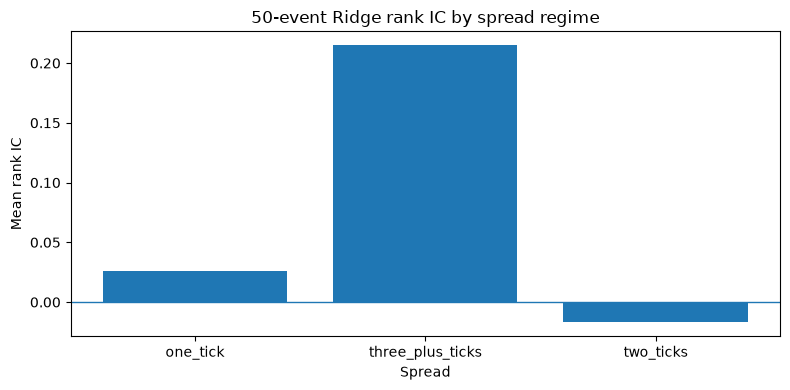

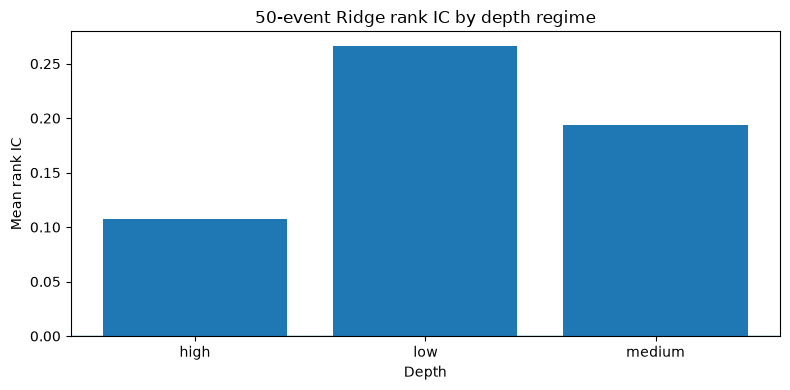

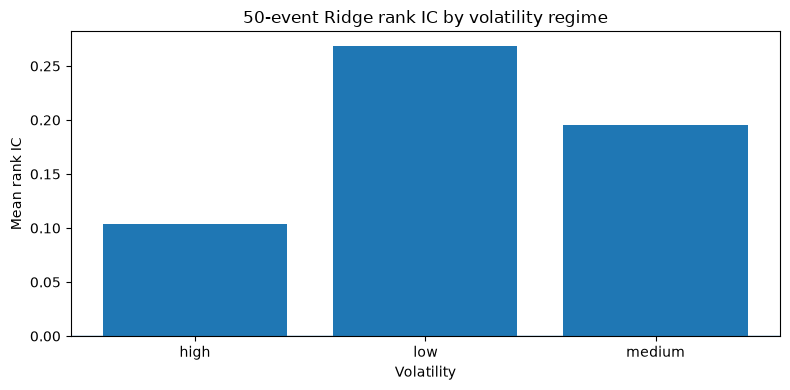

In [3]:
primary = regime_summary.loc[regime_summary["horizon"] == 50].copy()

for regime_type in ["spread", "depth", "volatility"]:
    subset = primary.loc[primary["regime_type"] == regime_type]
    plt.figure(figsize=(8, 4))
    plt.bar(subset["regime_label"], subset["ridge_rank_ic_mean"])
    plt.axhline(0.0, linewidth=1)
    plt.title(f"50-event Ridge rank IC by {regime_type} regime")
    plt.xlabel(regime_type.capitalize())
    plt.ylabel("Mean rank IC")
    plt.tight_layout()
    plt.show()


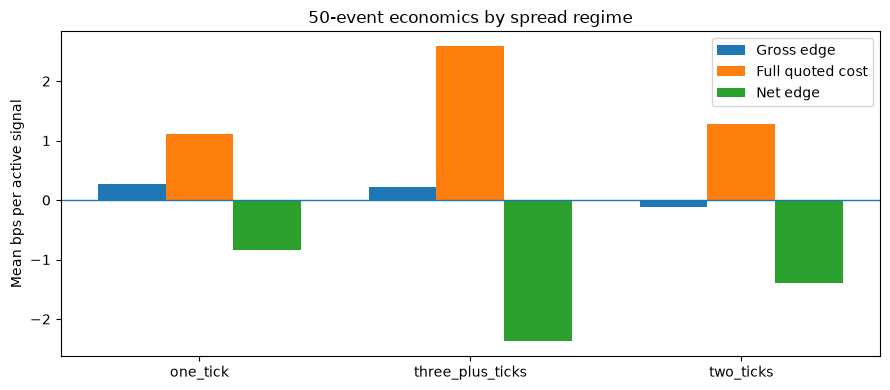

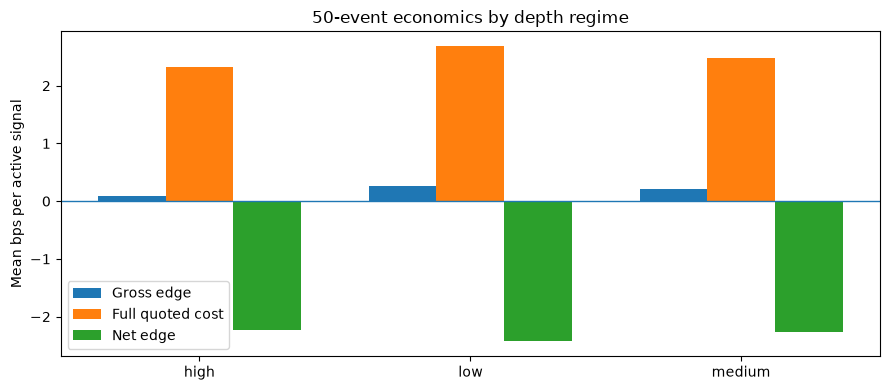

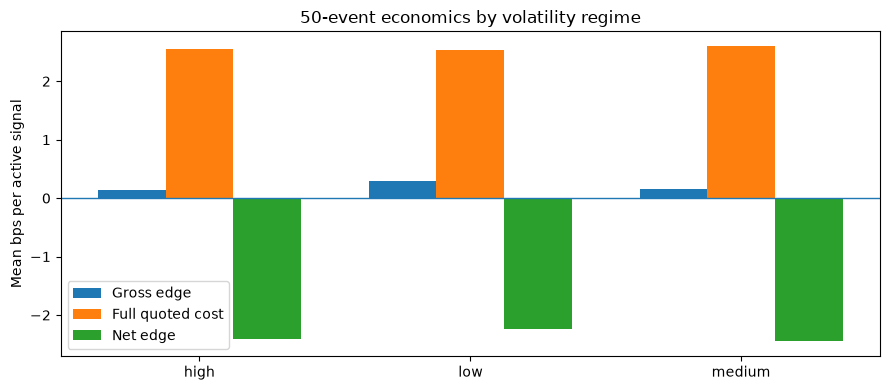

In [4]:
for regime_type in ["spread", "depth", "volatility"]:
    subset = primary.loc[primary["regime_type"] == regime_type]
    x = np.arange(len(subset))
    width = 0.25

    plt.figure(figsize=(9, 4))
    plt.bar(x - width, subset["mean_gross_return_active_bps_mean"], width, label="Gross edge")
    plt.bar(x, subset["mean_full_estimated_cost_active_bps_mean"], width, label="Full quoted cost")
    plt.bar(x + width, subset["mean_net_return_active_bps_mean"], width, label="Net edge")
    plt.xticks(x, subset["regime_label"])
    plt.axhline(0.0, linewidth=1)
    plt.title(f"50-event economics by {regime_type} regime")
    plt.ylabel("Mean bps per active signal")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 3. Confidence-threshold sensitivity

The full quoted-cost case is used below. A higher threshold should reduce activity and ideally improve gross edge per active signal.


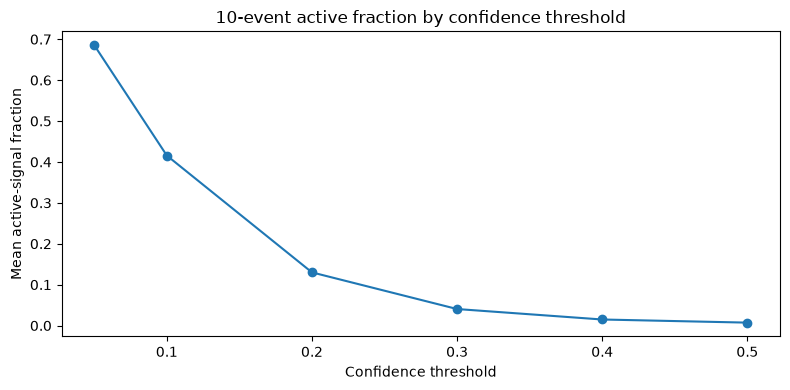

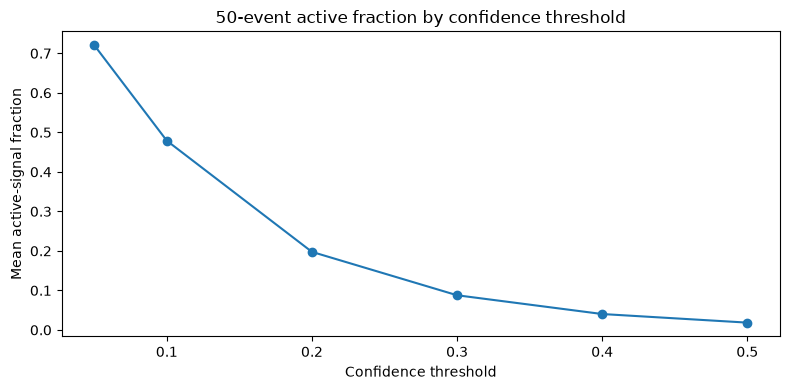

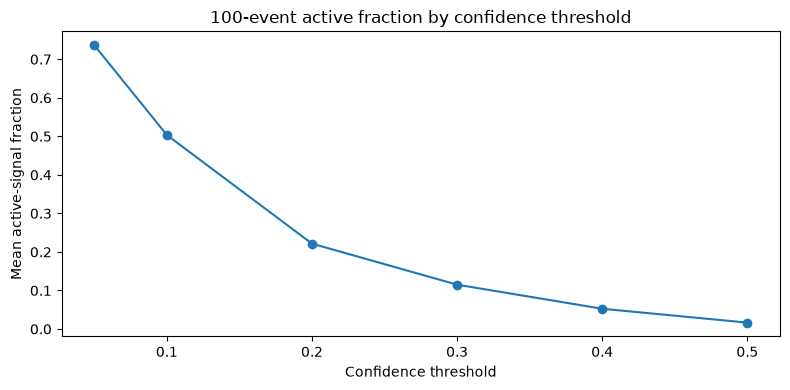

In [5]:
full_cost = sensitivity_summary.loc[
    sensitivity_summary["cost_fraction"] == 1.0
].copy()

for horizon in [10, 50, 100]:
    subset = full_cost.loc[full_cost["horizon"] == horizon].sort_values("confidence_threshold")
    plt.figure(figsize=(8, 4))
    plt.plot(subset["confidence_threshold"], subset["active_signal_fraction_mean"], marker="o")
    plt.title(f"{horizon}-event active fraction by confidence threshold")
    plt.xlabel("Confidence threshold")
    plt.ylabel("Mean active-signal fraction")
    plt.tight_layout()
    plt.show()


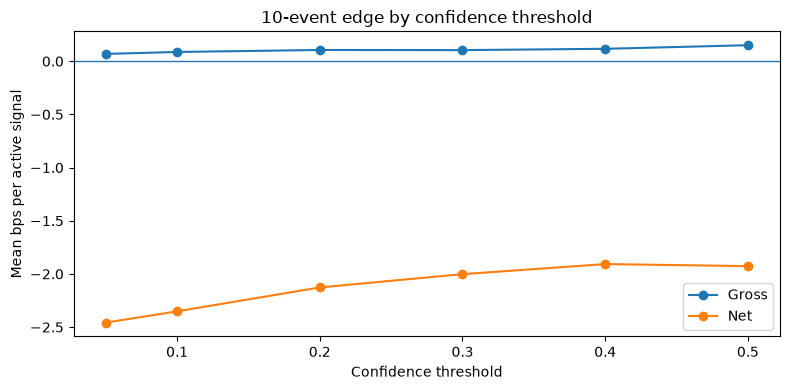

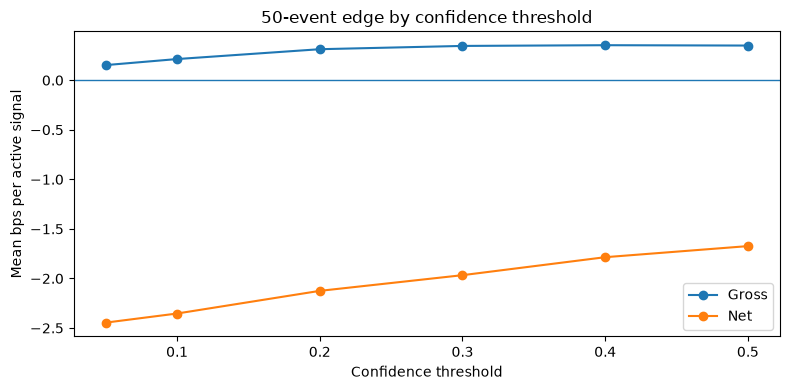

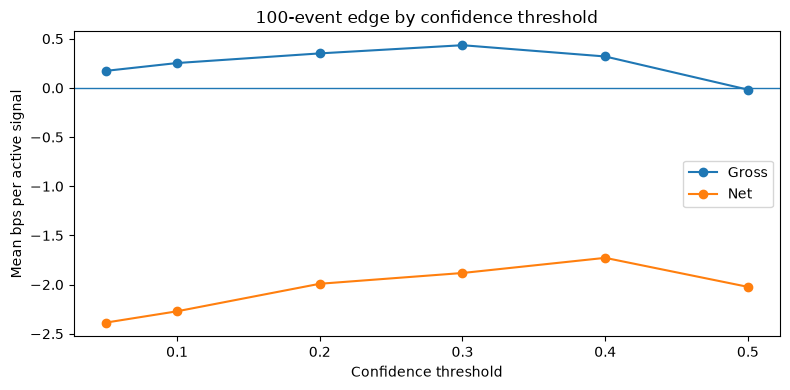

In [6]:
for horizon in [10, 50, 100]:
    subset = full_cost.loc[full_cost["horizon"] == horizon].sort_values("confidence_threshold")
    plt.figure(figsize=(8, 4))
    plt.plot(subset["confidence_threshold"], subset["mean_gross_return_active_bps_mean"], marker="o", label="Gross")
    plt.plot(subset["confidence_threshold"], subset["mean_net_return_active_bps_mean"], marker="o", label="Net")
    plt.axhline(0.0, linewidth=1)
    plt.title(f"{horizon}-event edge by confidence threshold")
    plt.xlabel("Confidence threshold")
    plt.ylabel("Mean bps per active signal")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 4. Cost sensitivity at the current 0.10 threshold


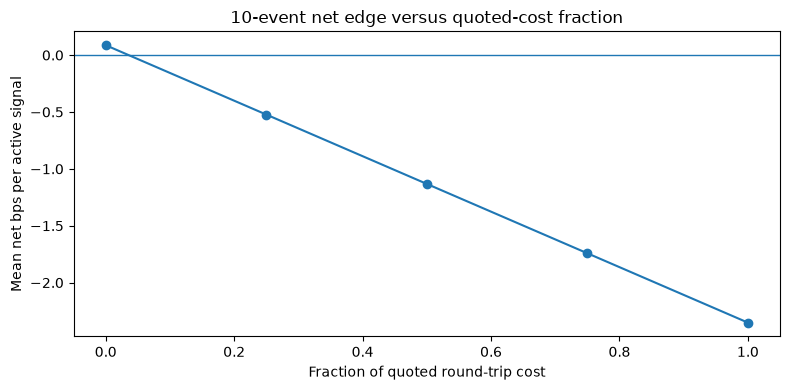

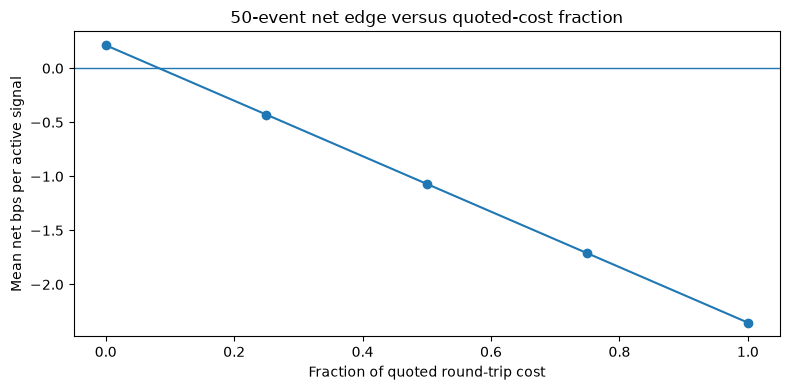

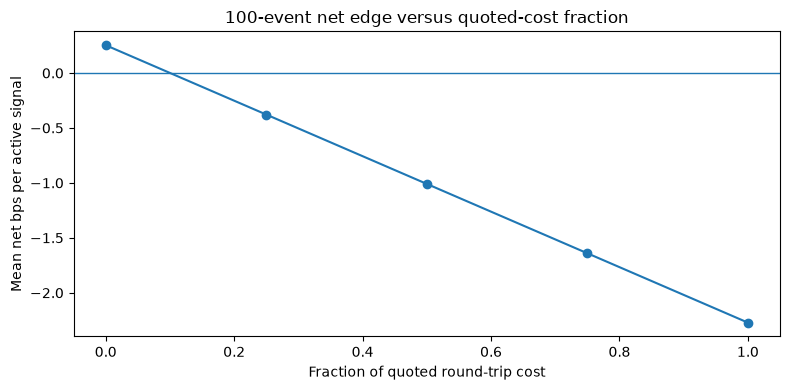

In [7]:
threshold_point_one = sensitivity_summary.loc[
    sensitivity_summary["confidence_threshold"] == 0.10
].copy()

for horizon in [10, 50, 100]:
    subset = threshold_point_one.loc[
        threshold_point_one["horizon"] == horizon
    ].sort_values("cost_fraction")
    plt.figure(figsize=(8, 4))
    plt.plot(subset["cost_fraction"], subset["mean_net_return_active_bps_mean"], marker="o")
    plt.axhline(0.0, linewidth=1)
    plt.title(f"{horizon}-event net edge versus quoted-cost fraction")
    plt.xlabel("Fraction of quoted round-trip cost")
    plt.ylabel("Mean net bps per active signal")
    plt.tight_layout()
    plt.show()


## 5. Spread-confidence intersections

This section tests whether high-confidence signals become more useful when the spread is narrow.


In [8]:
spread_50 = spread_confidence_summary.loc[
    spread_confidence_summary["horizon"] == 50
].copy()

pivot = spread_50.pivot(
    index="spread_regime",
    columns="confidence_threshold",
    values="mean_net_return_active_bps_mean",
)
pivot


confidence_threshold,0.05,0.10,0.20,0.30,0.40,0.50
spread_regime,,,,,,
one_tick,-0.967903,-0.832817,-0.773744,0.000119,0.102857,0.102861
three_plus_ticks,-2.460224,-2.372950,-2.146658,-1.990676,-1.822171,-1.719146
two_ticks,-1.391702,-1.402145,-1.026628,-1.352774,-0.923396,-0.923396


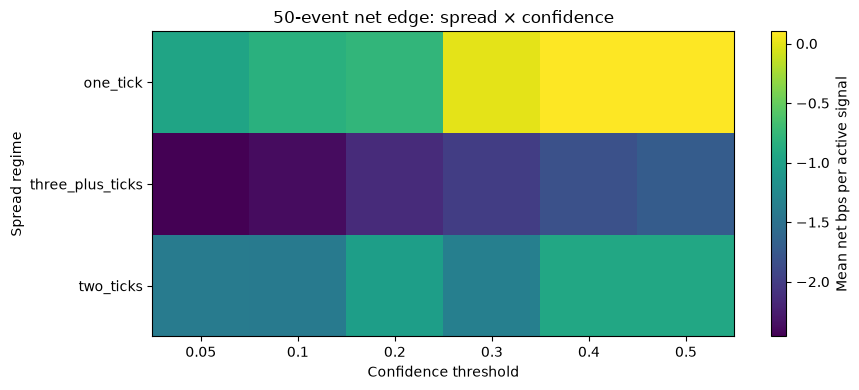

In [9]:
matrix = pivot.to_numpy(dtype=float)
plt.figure(figsize=(9, 4))
image = plt.imshow(matrix, aspect="auto")
plt.colorbar(image, label="Mean net bps per active signal")
plt.yticks(np.arange(len(pivot.index)), pivot.index)
plt.xticks(np.arange(len(pivot.columns)), pivot.columns)
plt.xlabel("Confidence threshold")
plt.ylabel("Spread regime")
plt.title("50-event net edge: spread × confidence")
plt.tight_layout()
plt.show()


## 6. Candidate development configurations

This table ranks development-only cells by mean gross edge, while retaining activity and full-cost net results. It is diagnostic, not evidence from an untouched test set.


In [10]:
candidate_columns = [
    "horizon",
    "spread_regime",
    "confidence_threshold",
    "active_signal_fraction_mean",
    "mean_gross_return_active_bps_mean",
    "mean_full_estimated_cost_active_bps_mean",
    "mean_net_return_active_bps_mean",
    "break_even_cost_fraction_mean",
    "positive_gross_fold",
    "positive_net_fold",
]
spread_confidence_summary[candidate_columns].sort_values(
    "mean_gross_return_active_bps_mean",
    ascending=False,
).head(20)


,horizon,spread_regime,confidence_threshold,active_signal_fraction_mean,mean_gross_return_active_bps_mean,mean_full_estimated_cost_active_bps_mean,mean_net_return_active_bps_mean,break_even_cost_fraction_mean,positive_gross_fold,positive_net_fold
21,50,one_tick,0.30,0.300000,0.651141,0.651023,0.000119,0.590521,3,1
22,50,one_tick,0.40,0.250000,0.497062,0.394206,0.102857,0.470529,2,1
45,100,three_plus_ticks,0.30,0.113939,0.413595,2.344309,-1.930714,0.189470,4,0
23,50,one_tick,0.50,0.050000,0.394508,0.291647,0.102861,0.270538,1,1
44,100,three_plus_ticks,0.20,0.220406,0.366006,2.355510,-1.989505,0.169793,5,0
37,100,one_tick,0.10,0.500000,0.345562,0.815828,-0.470266,1.098250,2,2
27,50,three_plus_ticks,0.30,0.086741,0.343039,2.333715,-1.990676,0.153363,5,0
28,50,three_plus_ticks,0.40,0.039591,0.336297,2.158467,-1.822171,0.161056,5,0
29,50,three_plus_ticks,0.50,0.017899,0.323144,2.042290,-1.719146,0.159869,5,0
26,50,three_plus_ticks,0.20,0.195970,0.313099,2.459758,-2.146658,0.133265,5,0


## Questions to answer before Phase C

1. Which regime has the highest and most stable rank IC?
2. Does narrowing the spread materially reduce the execution-cost gap?
3. Does increasing confidence improve gross edge monotonically?
4. At what cost fraction, if any, does mean net edge cross zero?
5. Are any apparently attractive cells supported across most folds, or driven by one fold?
6. Does the 50-event horizon remain the primary development horizon?
